In [1]:
!pip install torch-cka

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Load Dataset

In [1]:
import random
from torch.utils.data import Subset
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

data_dir = "./imagenet_validation"      # Download from https://www.kaggle.com/datasets/tusonggao/imagenet-validation-dataset

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
])

dataset_base = datasets.ImageFolder(root=data_dir, transform=transform)

# n_samples = 50  # ViT
n_samples = 25  # Dino
indices = random.sample(range(len(dataset_base)), n_samples)
subset = Subset(dataset_base, indices)

loader = DataLoader(
    subset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
)

def get_affine_dataset(translation=None, rotation=0, scale=None, shear=None):
    transform_affine = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.RandomAffine(degrees=rotation, translate=translation, scale=scale, shear=shear),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225)
        ),
    ])

    dataset_affine = datasets.ImageFolder(root=data_dir, transform=transform_affine)
    subset_affine = Subset(dataset_affine, indices)

    return DataLoader(
        subset_affine,
        batch_size=64,
        shuffle=False,
        num_workers=4,
    )

num_classes = len(dataset_base.classes)
print("Dataset size:", len(loader.dataset))
print("Classes:", num_classes)

Dataset size: 25
Classes: 1000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


# Utils

In [3]:
import torch
import gc


def clear_gpu_memory():
    # 1. Delete model and optimizer variables if they exist
    # You might need to manually 'del model' and 'del optimizer'
    # before calling this if they are in the global scope.

    # 2. Trigger Python's garbage collector
    gc.collect()

    # 3. Clear the PyTorch CUDA cache
    torch.cuda.empty_cache()

    # 4. (Optional) If you are using DistributedDataParallel or similar
    # it helps to reset the peak memory stats
    torch.cuda.reset_peak_memory_stats()

    print("GPU memory cleared.")

In [4]:
import pickle
import os


results_dir = "./cka_results/"
os.makedirs(results_dir, exist_ok=True)


def save_to_pickle(cka_comparison, cka_results, name_a, name_b):
    with open(results_dir + f'cka_comparison_{name_a}_{name_b}.pkl', 'wb') as f:
        pickle.dump(cka_comparison, f)

    with open(results_dir + f'cka_results_{name_a}_{name_b}.pkl', 'wb') as f:
        pickle.dump(cka_results, f)

def load_from_pickle(name_a, name_b):
    with open(results_dir + f'cka_comparison_{name_a}_{name_b}.pkl', 'rb') as f:
        cka_comparison = pickle.load(f)

    with open(results_dir + f'cka_results_{name_a}_{name_b}.pkl', 'rb') as f:
        cka_results = pickle.load(f)

    return cka_comparison, cka_results

# CKA

In [5]:
from torch_cka import CKA
import matplotlib.pyplot as plt
import seaborn as sns
import timm


def plot_cka_matrix(results):
    # Extract the CKA values and layer names
    # results['CKA'] is the actual similarity matrix
    cka_matrix = results['CKA']
    model1_layers = results['model1_layers']
    model2_layers = results['model2_layers']

    # 2. Set up the plotting environment
    plt.figure(figsize=(10, 8))

    # 3. Create the heatmap
    # We use 'magma' or 'viridis' for high contrast
    ax = sns.heatmap(
        cka_matrix,
        annot=False,
        fmt=".2f",
        cmap='magma',
        xticklabels=model2_layers,
        yticklabels=model1_layers
    )
    ax.invert_yaxis()

    # 4. Add labels and formatting
    plt.title("CKA Similarity Matrix", fontsize=15)
    plt.xlabel(f"Layers: {results['model2_name']}", fontsize=12)
    plt.ylabel(f"Layers: {results['model1_name']}", fontsize=12)

    # Rotate labels if there are many layers to prevent overlapping
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

### ViT Base

In [42]:
model = timm.create_model(
    "vit_base_patch16_224", pretrained=True, num_classes=num_classes
)

available_layers = [name for name, _ in model.named_modules()]
print(available_layers)

layers_to_compare = ["patch_embed"]
layers_to_compare += [f"blocks.{i}" for i in range(0, 12)]
layers_to_compare += ["norm"]
layers_to_compare

['', 'patch_embed', 'patch_embed.proj', 'patch_embed.norm', 'pos_drop', 'patch_drop', 'norm_pre', 'blocks', 'blocks.0', 'blocks.0.norm1', 'blocks.0.attn', 'blocks.0.attn.qkv', 'blocks.0.attn.q_norm', 'blocks.0.attn.k_norm', 'blocks.0.attn.attn_drop', 'blocks.0.attn.norm', 'blocks.0.attn.proj', 'blocks.0.attn.proj_drop', 'blocks.0.ls1', 'blocks.0.drop_path1', 'blocks.0.norm2', 'blocks.0.mlp', 'blocks.0.mlp.fc1', 'blocks.0.mlp.act', 'blocks.0.mlp.drop1', 'blocks.0.mlp.norm', 'blocks.0.mlp.fc2', 'blocks.0.mlp.drop2', 'blocks.0.ls2', 'blocks.0.drop_path2', 'blocks.1', 'blocks.1.norm1', 'blocks.1.attn', 'blocks.1.attn.qkv', 'blocks.1.attn.q_norm', 'blocks.1.attn.k_norm', 'blocks.1.attn.attn_drop', 'blocks.1.attn.norm', 'blocks.1.attn.proj', 'blocks.1.attn.proj_drop', 'blocks.1.ls1', 'blocks.1.drop_path1', 'blocks.1.norm2', 'blocks.1.mlp', 'blocks.1.mlp.fc1', 'blocks.1.mlp.act', 'blocks.1.mlp.drop1', 'blocks.1.mlp.norm', 'blocks.1.mlp.fc2', 'blocks.1.mlp.drop2', 'blocks.1.ls2', 'blocks.1.dro

['patch_embed',
 'blocks.0',
 'blocks.1',
 'blocks.2',
 'blocks.3',
 'blocks.4',
 'blocks.5',
 'blocks.6',
 'blocks.7',
 'blocks.8',
 'blocks.9',
 'blocks.10',
 'blocks.11',
 'norm']

##### Rotate 90

In [43]:
model_1_name = "ViT Base"
model_2_name = "ViT Base Rotated 90º"

model_1 = timm.create_model(
    "vit_base_patch16_224", pretrained=True, num_classes=num_classes
).to(device)

model_2 = timm.create_model(
    "vit_base_patch16_224", pretrained=True, num_classes=num_classes
).to(device)

cka = CKA(
    model_1,
    model_2,
    model1_name=model_1_name,
    model2_name=model_2_name,
    model1_layers=layers_to_compare,
    model2_layers=layers_to_compare,
    device=device,
)

loader_affine = get_affine_dataset(rotation=(-90, -90))
cka.compare(loader, loader_affine)
results = cka.export()

save_to_pickle(cka, results, model_1_name, model_2_name)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
| Comparing features |: 100%|██████████| 1

In [55]:
del model_1
del model_2
clear_gpu_memory()

GPU memory cleared.


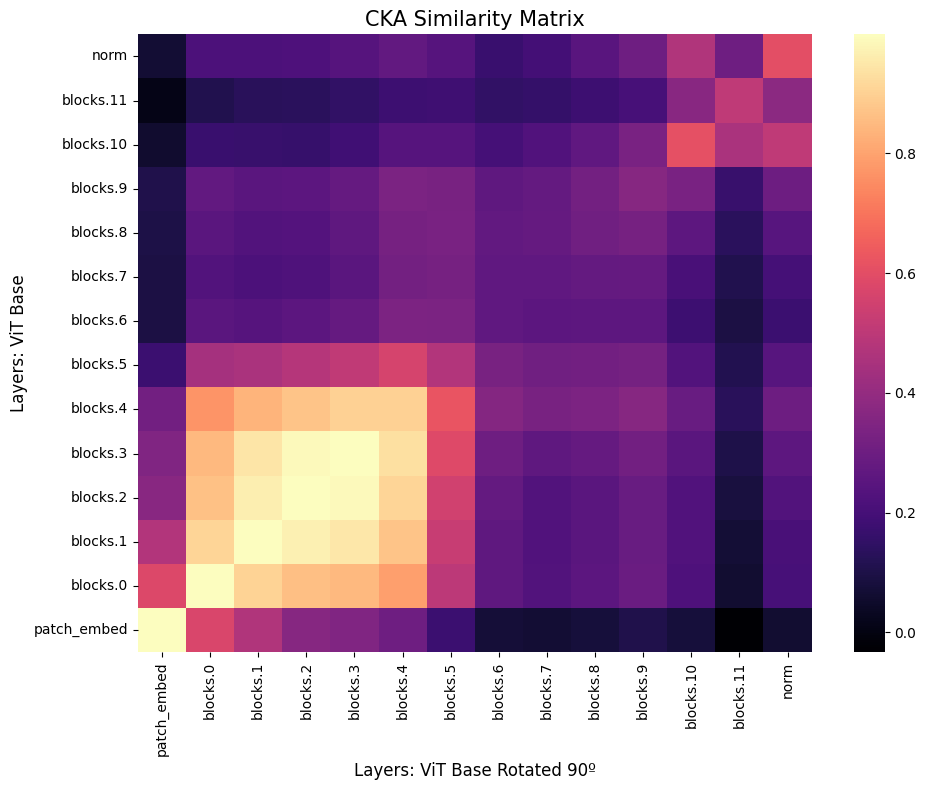

In [47]:
model_1_name = "ViT Base"
model_2_name = "ViT Base Rotated 90º"

cka, results = load_from_pickle(model_1_name, model_2_name)

plot_cka_matrix(results)

In [49]:
clear_gpu_memory()

GPU memory cleared.


##### Rotate 180

In [50]:
model_1_name = "ViT Base"
model_2_name = "ViT Base Rotated 180º"

model_1 = timm.create_model(
    "vit_base_patch16_224", pretrained=True, num_classes=num_classes
).to(device)

model_2 = timm.create_model(
    "vit_base_patch16_224", pretrained=True, num_classes=num_classes
).to(device)

cka = CKA(
    model_1,
    model_2,
    model1_name=model_1_name,
    model2_name=model_2_name,
    model1_layers=layers_to_compare,
    model2_layers=layers_to_compare,
    device=device,
)

loader_affine = get_affine_dataset(rotation=(180, 180))
cka.compare(loader, loader_affine)
results = cka.export()

save_to_pickle(cka, results, model_1_name, model_2_name)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
| Comparing features |: 100%|██████████| 1

In [59]:
del model_1
del model_2
clear_gpu_memory()

GPU memory cleared.


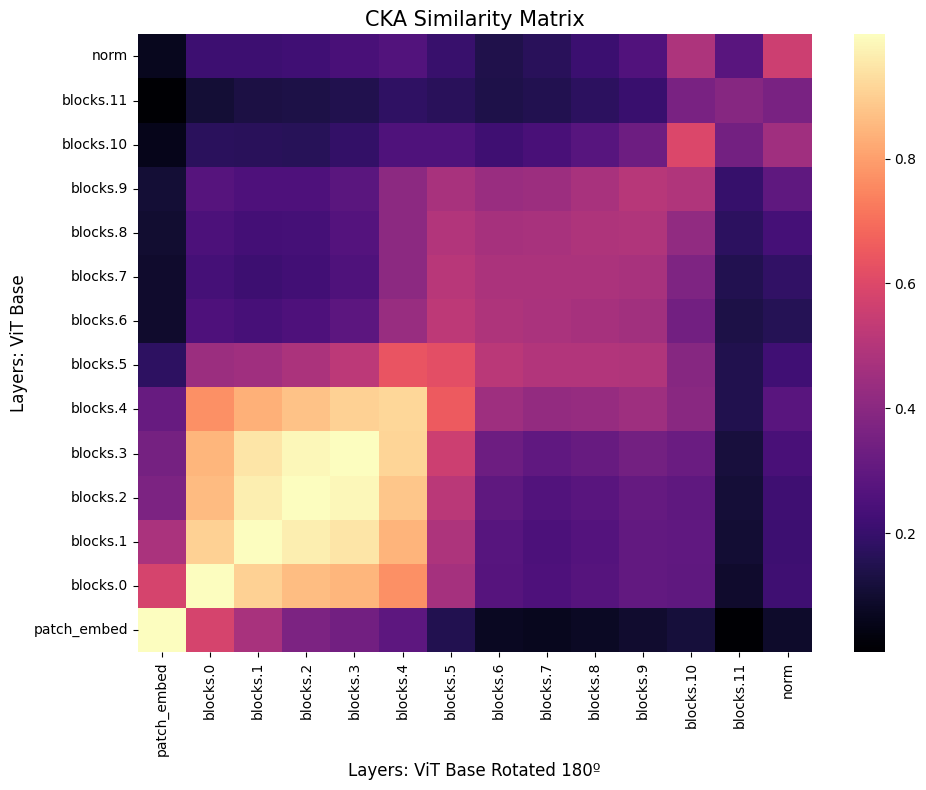

In [53]:
model_1_name = "ViT Base"
model_2_name = "ViT Base Rotated 180º"

cka, results = load_from_pickle(model_1_name, model_2_name)

plot_cka_matrix(results)

In [52]:
clear_gpu_memory()

GPU memory cleared.


##### Scale x2

In [60]:
model_1_name = "ViT Base"
model_2_name = "ViT Base Scale x2"

model_1 = timm.create_model(
    "vit_base_patch16_224", pretrained=True, num_classes=num_classes
).to(device)

model_2 = timm.create_model(
    "vit_base_patch16_224", pretrained=True, num_classes=num_classes
).to(device)

cka = CKA(
    model_1,
    model_2,
    model1_name=model_1_name,
    model2_name=model_2_name,
    model1_layers=layers_to_compare,
    model2_layers=layers_to_compare,
    device=device,
)

loader_affine = get_affine_dataset(scale=(2.0, 2.0))
cka.compare(loader, loader_affine)
results = cka.export()

save_to_pickle(cka, results, model_1_name, model_2_name)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
| Comparing features |: 100%|██████████| 1

In [61]:
del model_1
del model_2
clear_gpu_memory()

GPU memory cleared.


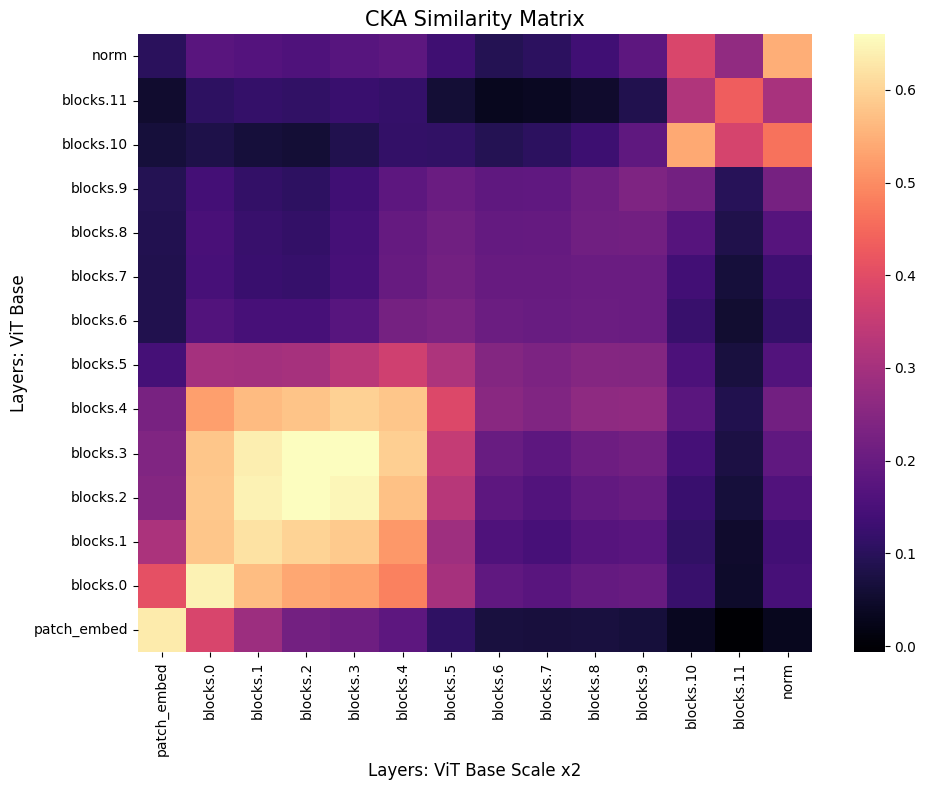

In [62]:
model_1_name = "ViT Base"
model_2_name = "ViT Base Scale x2"

cka, results = load_from_pickle(model_1_name, model_2_name)

plot_cka_matrix(results)

In [64]:
clear_gpu_memory()

GPU memory cleared.


##### Shear 50

In [65]:
model_1_name = "ViT Base"
model_2_name = "ViT Base Shear 50"

model_1 = timm.create_model(
    "vit_base_patch16_224", pretrained=True, num_classes=num_classes
).to(device)

model_2 = timm.create_model(
    "vit_base_patch16_224", pretrained=True, num_classes=num_classes
).to(device)

cka = CKA(
    model_1,
    model_2,
    model1_name=model_1_name,
    model2_name=model_2_name,
    model1_layers=layers_to_compare,
    model2_layers=layers_to_compare,
    device=device,
)

loader_affine = get_affine_dataset(shear=(50, 50))
cka.compare(loader, loader_affine)
results = cka.export()

save_to_pickle(cka, results, model_1_name, model_2_name)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
| Comparing features |: 100%|██████████| 1

In [66]:
del model_1
del model_2
clear_gpu_memory()

GPU memory cleared.


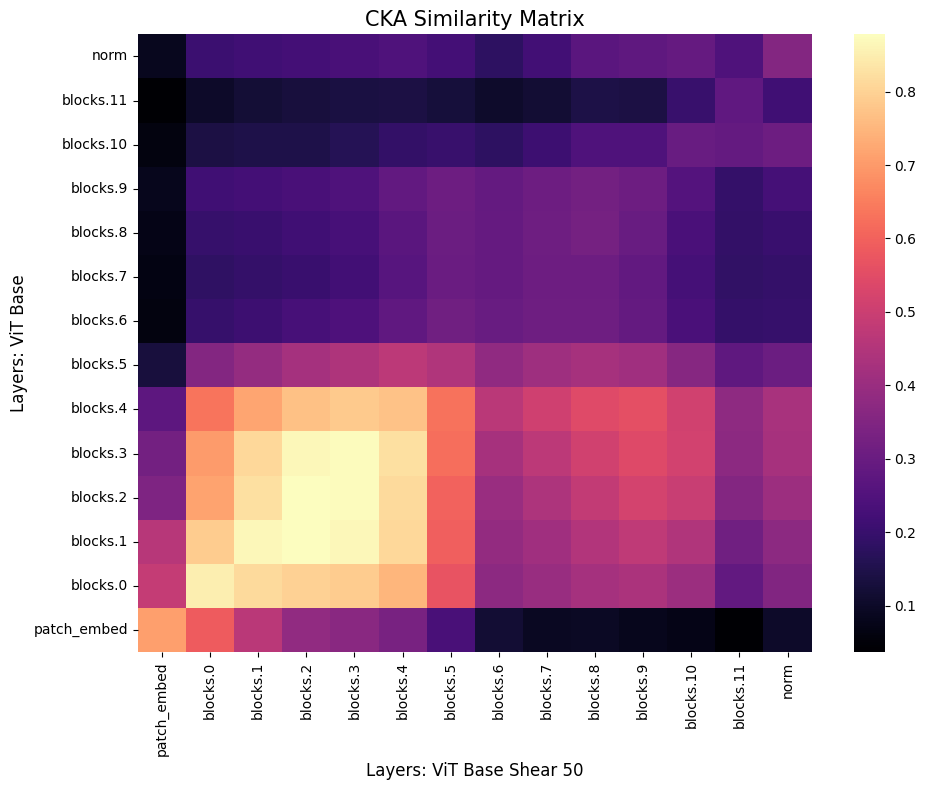

In [67]:
model_1_name = "ViT Base"
model_2_name = "ViT Base Shear 50"

cka, results = load_from_pickle(model_1_name, model_2_name)

plot_cka_matrix(results)

In [68]:
clear_gpu_memory()

GPU memory cleared.


### Dino Base

In [6]:
# model = torch.hub.load("facebookresearch/dinov2", "dinov2_vitb14_lc")

# available_layers = [name for name, module in model.named_modules()]
# print(available_layers)

layers_to_compare = ["backbone.patch_embed"]
layers_to_compare += [f"backbone.blocks.{i}" for i in range(0, 12)]
layers_to_compare += ["backbone.norm"]
layers_to_compare

['backbone.patch_embed',
 'backbone.blocks.0',
 'backbone.blocks.1',
 'backbone.blocks.2',
 'backbone.blocks.3',
 'backbone.blocks.4',
 'backbone.blocks.5',
 'backbone.blocks.6',
 'backbone.blocks.7',
 'backbone.blocks.8',
 'backbone.blocks.9',
 'backbone.blocks.10',
 'backbone.blocks.11',
 'backbone.norm']

##### Rotate 90

In [7]:
model_1_name = "Dino Base"
model_2_name = "Dino Base Rotated 90º"

model_1 = torch.hub.load("facebookresearch/dinov2", "dinov2_vitb14_lc").to(device)
model_2 = torch.hub.load("facebookresearch/dinov2", "dinov2_vitb14_lc").to(device)

cka = CKA(
    model_1,
    model_2,
    model1_name=model_1_name,
    model2_name=model_2_name,
    model1_layers=layers_to_compare,
    model2_layers=layers_to_compare,
    device=device,
)

loader_affine = get_affine_dataset(rotation=(-90, -90))
cka.compare(loader, loader_affine)
results = cka.export()

save_to_pickle(cka, results, model_1_name, model_2_name)

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive

In [8]:
del model_1
del model_2
clear_gpu_memory()

GPU memory cleared.


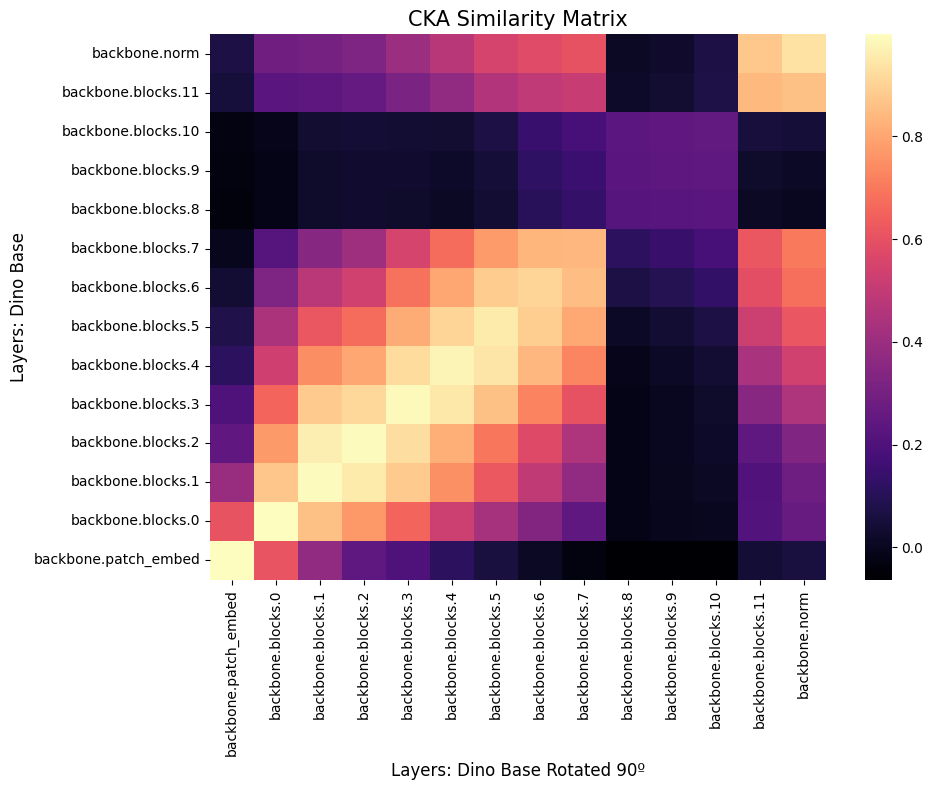

In [9]:
model_1_name = "Dino Base"
model_2_name = "Dino Base Rotated 90º"

cka, results = load_from_pickle(model_1_name, model_2_name)

plot_cka_matrix(results)

In [10]:
clear_gpu_memory()

GPU memory cleared.


##### Rotate 180

In [11]:
model_1_name = "Dino Base"
model_2_name = "Dino Base Rotated 180º"

model_1 = torch.hub.load("facebookresearch/dinov2", "dinov2_vitb14_lc").to(device)
model_2 = torch.hub.load("facebookresearch/dinov2", "dinov2_vitb14_lc").to(device)

cka = CKA(
    model_1,
    model_2,
    model1_name=model_1_name,
    model2_name=model_2_name,
    model1_layers=layers_to_compare,
    model2_layers=layers_to_compare,
    device=device,
)

loader_affine = get_affine_dataset(rotation=(180, 180))
cka.compare(loader, loader_affine)
results = cka.export()

save_to_pickle(cka, results, model_1_name, model_2_name)

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the 

In [12]:
del model_1
del model_2
clear_gpu_memory()

GPU memory cleared.


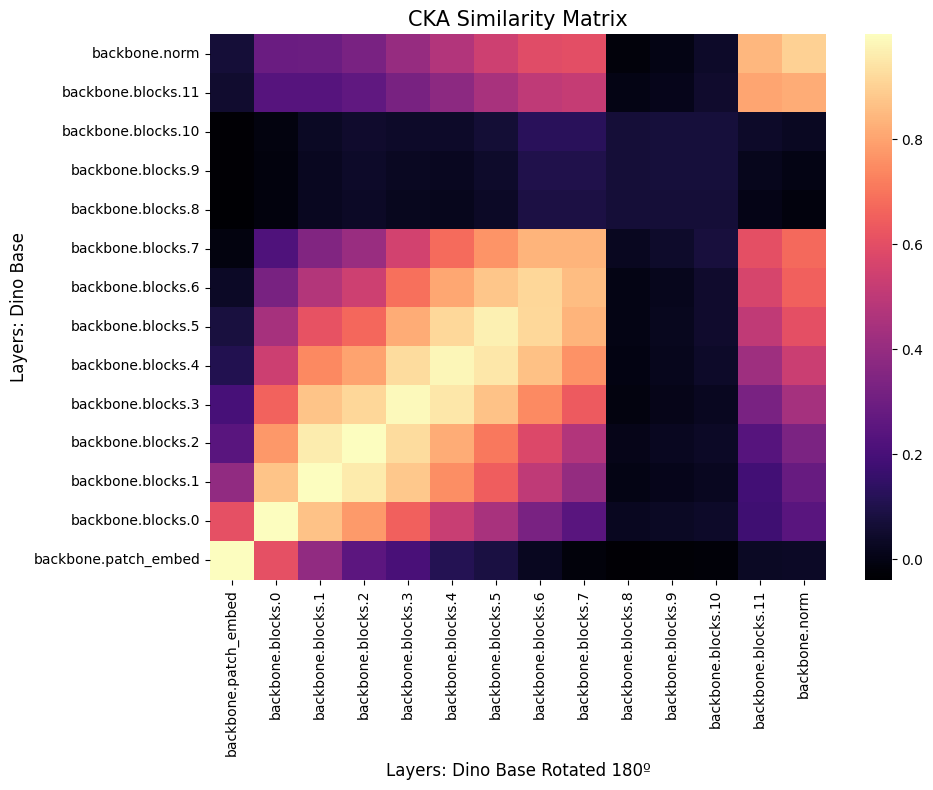

In [13]:
model_1_name = "Dino Base"
model_2_name = "Dino Base Rotated 180º"

cka, results = load_from_pickle(model_1_name, model_2_name)

plot_cka_matrix(results)

In [14]:
clear_gpu_memory()

GPU memory cleared.


##### Scale x2

In [15]:
model_1_name = "Dino Base"
model_2_name = "Dino Base Scale x2"

model_1 = torch.hub.load("facebookresearch/dinov2", "dinov2_vitb14_lc").to(device)
model_2 = torch.hub.load("facebookresearch/dinov2", "dinov2_vitb14_lc").to(device)

cka = CKA(
    model_1,
    model_2,
    model1_name=model_1_name,
    model2_name=model_2_name,
    model1_layers=layers_to_compare,
    model2_layers=layers_to_compare,
    device=device,
)

loader_affine = get_affine_dataset(scale=(2.0, 2.0))
cka.compare(loader, loader_affine)
results = cka.export()

save_to_pickle(cka, results, model_1_name, model_2_name)

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the 

In [16]:
del model_1
del model_2
clear_gpu_memory()

GPU memory cleared.


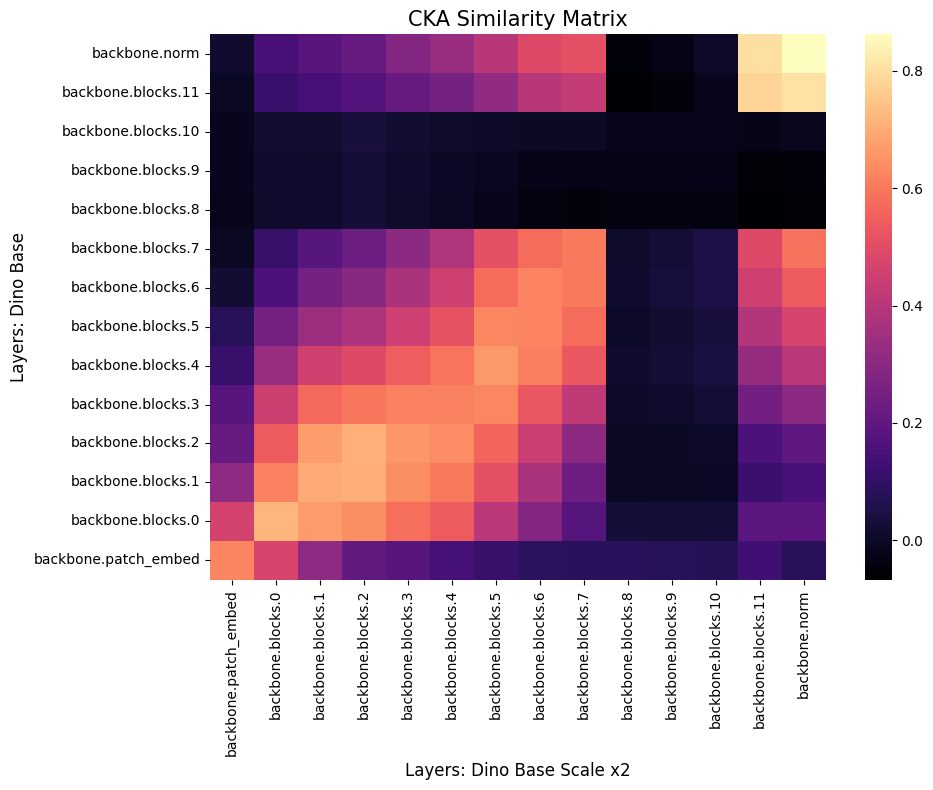

In [17]:
model_1_name = "Dino Base"
model_2_name = "Dino Base Scale x2"

cka, results = load_from_pickle(model_1_name, model_2_name)

plot_cka_matrix(results)

In [18]:
clear_gpu_memory()

GPU memory cleared.


##### Shear 50

In [19]:
model_1_name = "Dino Base"
model_2_name = "Dino Base Shear 50"

model_1 = torch.hub.load("facebookresearch/dinov2", "dinov2_vitb14_lc").to(device)
model_2 = torch.hub.load("facebookresearch/dinov2", "dinov2_vitb14_lc").to(device)

cka = CKA(
    model_1,
    model_2,
    model1_name=model_1_name,
    model2_name=model_2_name,
    model1_layers=layers_to_compare,
    model2_layers=layers_to_compare,
    device=device,
)

loader_affine = get_affine_dataset(shear=(50, 50))
cka.compare(loader, loader_affine)
results = cka.export()

save_to_pickle(cka, results, model_1_name, model_2_name)

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the 

In [20]:
del model_1
del model_2
clear_gpu_memory()

GPU memory cleared.


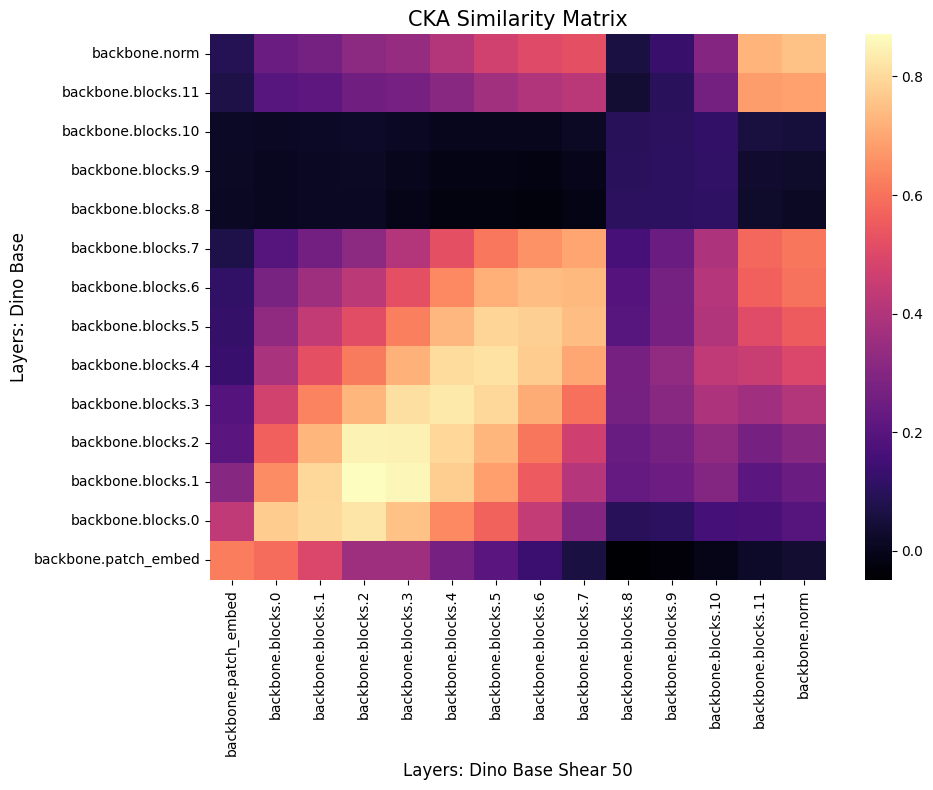

In [21]:
model_1_name = "Dino Base"
model_2_name = "Dino Base Shear 50"

cka, results = load_from_pickle(model_1_name, model_2_name)

plot_cka_matrix(results)

In [22]:
clear_gpu_memory()

GPU memory cleared.
